# Análise Exploratória de Dados — NPS

## Atendimento e perfil do cliente

Esta etapa da análise exploratória busca identificar características do cliente e aspectos do atendimento associados à satisfação, representada pelo `nps_score`. As análises são descritivas e exploratórias.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carrega a base tratada disponibilizada no repositório do projeto
url = 'https://raw.githubusercontent.com/Tiagoeneas12/Case_nps_preditivo_fase_tech_fiap/refs/heads/main/data/processed/desafio_nps_fase_1_clean.csv'
dados = pd.read_csv(url)


In [ ]:
dados.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

## 1. Perfil do cliente

### 1.1 Tempo de relacionamento × NPS

**Objetivo:** avaliar se o tempo de relacionamento do cliente com a empresa apresenta associação linear com o NPS.

**Hipótese:** não foi definida uma direção esperada para a relação, pois clientes novos e antigos podem apresentar diferentes níveis de satisfação conforme a experiência vivenciada.


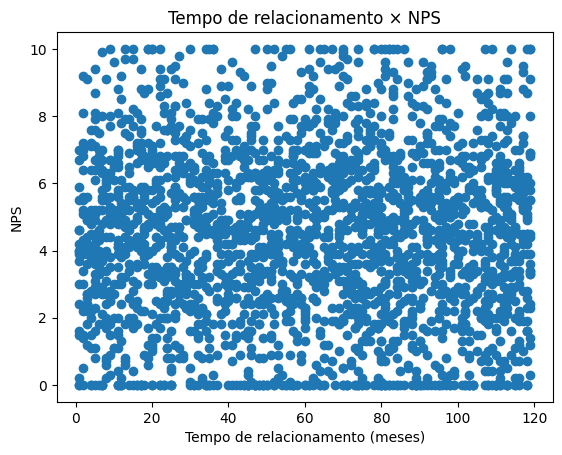

In [ ]:
plt.scatter(dados['customer_tenure_months'], dados['nps_score'])
plt.xlabel('Tempo de relacionamento (meses)')
plt.ylabel('NPS')
plt.title('Tempo de relacionamento × NPS')
plt.show()


In [ ]:
dados['customer_tenure_months'].corr(dados['nps_score'])

np.float64(-0.008989403153082557)

**Resultado:** O tempo de relacionamento com a empresa apresentou associação linear praticamente nula com o NPS r ≈ -0,009. O gráfico de dispersão também não evidencia tendência de aumento ou redução do NPS conforme o tempo de relacionamento.


### 1.2 Região do cliente × NPS

**Objetivo:** comparar a distribuição do NPS entre as regiões dos clientes e verificar se existem diferenças descritivas relevantes entre os grupos.


In [ ]:
dados['customer_region'].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

In [ ]:
# Separa o NPS por região para comparar as distribuições entre os grupos
nordeste = dados[dados['customer_region'] == 'Nordeste']['nps_score']
norte = dados[dados['customer_region'] == 'Norte']['nps_score']
sudeste = dados[dados['customer_region'] == 'Sudeste']['nps_score']
sul = dados[dados['customer_region'] == 'Sul']['nps_score']
centro_oeste = dados[dados['customer_region'] == 'Centro-Oeste']['nps_score']

In [ ]:
len(nordeste) + len(norte) + len(sul) + len(sudeste) + len(centro_oeste)

2465

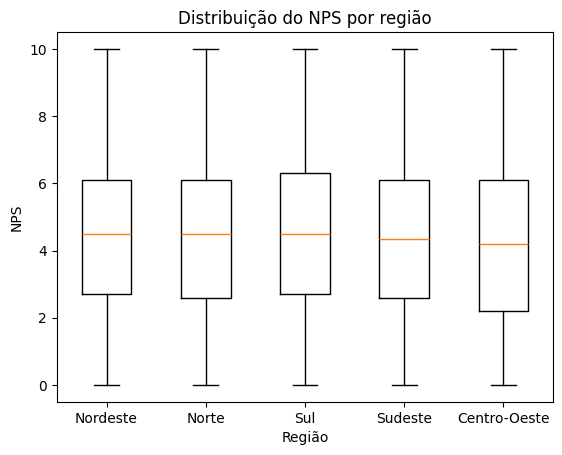

In [ ]:
plt.boxplot(
    [nordeste, norte, sul, sudeste, centro_oeste],
    tick_labels=['Nordeste', 'Norte', 'Sul', 'Sudeste', 'Centro-Oeste']
)
plt.ylabel('NPS')
plt.xlabel('Região')
plt.title('Distribuição do NPS por região')
plt.show()


In [ ]:
dados.groupby('customer_region')['nps_score'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_region,,,,,,,,
Centro-Oeste,461.0,4.198915,2.606576,0.0,2.2,4.20,6.1,10.0
Nordeste,475.0,4.436211,2.427635,0.0,2.7,4.50,6.1,10.0
Norte,502.0,4.375498,2.482557,0.0,2.6,4.50,6.1,10.0
Sudeste,514.0,4.387549,2.490340,0.0,2.6,4.35,6.1,10.0
Sul,513.0,4.483236,2.520795,0.0,2.7,4.50,6.3,10.0


**Resultado:** A análise do NPS por região mostrou comportamento semelhante entre as regiões, com médias, medianas e intervalos interquartis próximos. O Centro-Oeste apresentou Q1 mais baixo e dispersão ligeiramente maior, enquanto o Sul apresentou Q3 ligeiramente superior. De modo geral, a análise descritiva não indica diferenças relevantes na distribuição da satisfação entre as regiões.


### 1.3 Idade do cliente × NPS

**Objetivo:** avaliar se a idade do cliente apresenta associação linear com o NPS.


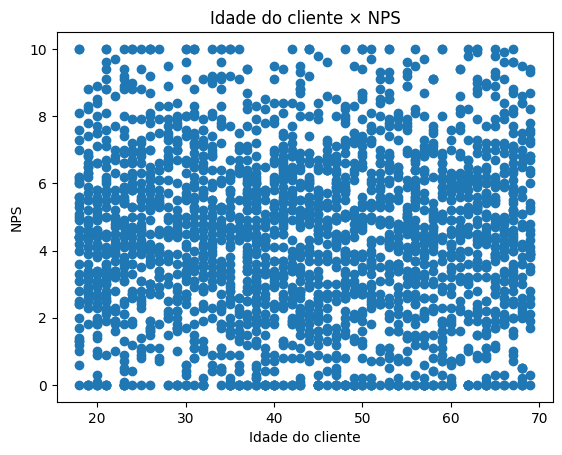

In [ ]:
plt.scatter(dados['customer_age'], dados['nps_score'])
plt.xlabel('Idade do cliente')
plt.ylabel('NPS')
plt.title('Idade do cliente × NPS')
plt.show()


In [ ]:
dados['customer_age'].corr(dados['nps_score'])

np.float64(-0.006857097810120417)

**Resultado:** A idade do cliente apresentou associação linear praticamente nula com o NPS (`r ≈ -0,007`). O gráfico de dispersão também não demonstra tendência aparente de aumento ou redução do NPS conforme a idade, indicando que, nesta base, a idade isoladamente não parece diferenciar os níveis de satisfação dos clientes.


### 1.4 Recompra em 30 dias × NPS

**Objetivo:** comparar a distribuição do NPS entre clientes que recompraram e os que não recompraram em até 30 dias.

**Hipótese:** clientes que realizam recompra em até 30 dias podem apresentar níveis de satisfação mais elevados.


In [ ]:
# Separa os clientes conforme a ocorrência de recompra em até 30 dias
nao_recompra = dados[dados['repeat_purchase_30d'] == 0]['nps_score']
sim_recompra = dados[dados['repeat_purchase_30d'] == 1]['nps_score']

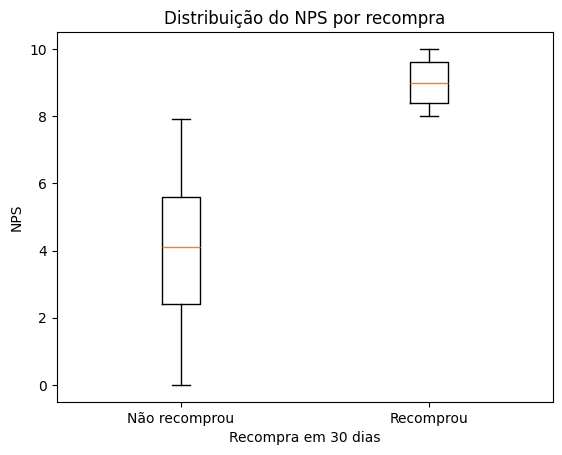

In [ ]:
plt.boxplot(
    [nao_recompra, sim_recompra],
    tick_labels=['Não recomprou', 'Recomprou']
)
plt.ylabel('NPS')
plt.xlabel('Recompra em 30 dias')
plt.title('Distribuição do NPS por recompra')
plt.show()


In [ ]:
dados.groupby('repeat_purchase_30d')['nps_score'].describe()

,count,mean,std,min,25%,50%,75%,max
repeat_purchase_30d,,,,,,,,
0,2255.0,3.946962,2.150184,0.0,2.4,4.1,5.6,7.9
1,210.0,9.019524,0.690295,8.0,8.4,9.0,9.6,10.0


In [ ]:
# Verifica se existem clientes que recompraram mesmo com NPS abaixo de 8
dados[
    (dados['repeat_purchase_30d'] == 1) &
    (dados['nps_score'] < 8)
]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score


In [ ]:
# Verifica se existem clientes que não recompraram mesmo com NPS igual ou superior a 8
dados[
    (dados['repeat_purchase_30d'] == 0) &
    (dados['nps_score'] >= 8)
]


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score


**Resultado:** A recompra em 30 dias apresentou forte associação com o NPS. Todos os registros com recompra possuem NPS igual ou superior a 8, enquanto todos os registros sem recompra apresentam NPS inferior a 8. A ausência de sobreposição entre os grupos indica uma separação perfeita nesta base e deve ser investigada antes de interpretar a recompra como fator explicativo da satisfação, especialmente porque a recompra pode ocorrer após a experiência avaliada pelo NPS.


## 2. Atendimento ao cliente

### 2.1 Número de contatos × NPS

**Objetivo:** avaliar se o número de contatos realizados pelo cliente com o atendimento apresenta associação linear com o NPS.

**Hipótese:** quanto maior o número de contatos com o atendimento, menor tende a ser o NPS, pois contatos repetidos podem sinalizar problemas na jornada do cliente.


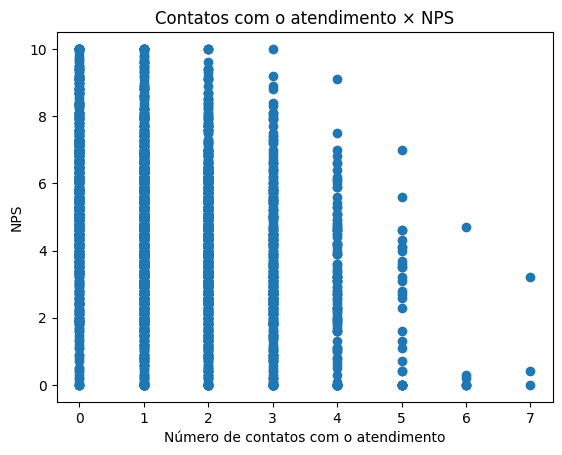

In [ ]:
plt.scatter(dados['customer_service_contacts'], dados['nps_score'])
plt.xlabel('Número de contatos com o atendimento')
plt.ylabel('NPS')
plt.title('Contatos com o atendimento × NPS')
plt.show()


In [ ]:
dados['customer_service_contacts'].corr(dados['nps_score'])

np.float64(-0.34751816703888433)

**Resultado:** O número de contatos com o atendimento apresentou correlação linear negativa de aproximadamente -0,348 com o NPS, indicando uma associação fraca a moderada. Observa-se que, a partir de quatro contatos, as avaliações mais altas se tornam menos frequentes, o que pode sinalizar a existência de problemas na jornada de compra que levam o cliente a buscar o atendimento repetidamente.


### 2.2 Tempo de resolução × NPS

**Objetivo:** avaliar se o tempo necessário para resolução do atendimento apresenta associação linear com o NPS.

**Hipótese:** quanto maior o tempo necessário para a resolução do problema, menor tende a ser o NPS.


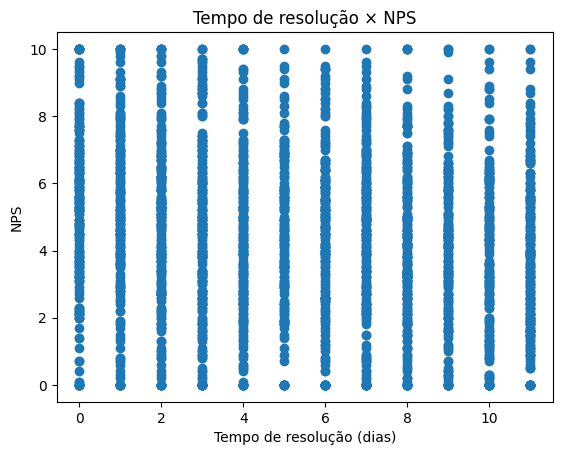

In [ ]:
plt.scatter(dados['resolution_time_days'], dados['nps_score'])
plt.xlabel('Tempo de resolução (dias)')
plt.ylabel('NPS')
plt.title('Tempo de resolução × NPS')
plt.show()


In [ ]:
dados['resolution_time_days'].corr(dados['nps_score'])

np.float64(-0.19041618969770613)

**Resultado:** O tempo de resolução apresentou correlação linear negativa de aproximadamente -0,190 com o NPS, indicando uma associação fraca. Embora a direção da relação esteja de acordo com a hipótese de que maiores tempos de resolução possam estar associados a menores níveis de satisfação, os dados não demonstram uma relação linear forte entre essas variáveis.

### 2.3 Número de reclamações × NPS

**Objetivo:** avaliar se o número de reclamações registradas pelo cliente apresenta associação linear com o NPS.

**Hipótese:** quanto maior o número de reclamações, menor tende a ser o NPS.


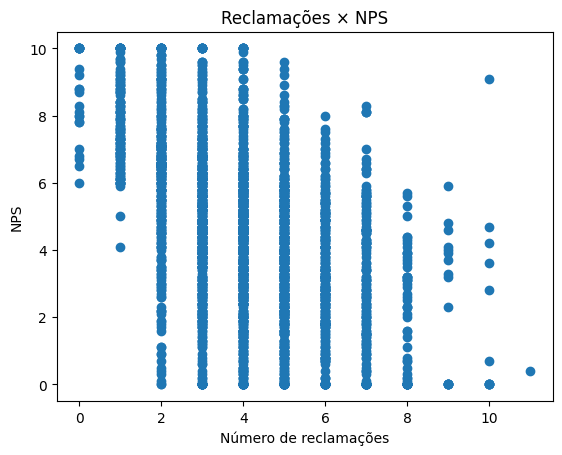

In [ ]:
plt.scatter(dados['complaints_count'], dados['nps_score'])
plt.xlabel('Número de reclamações')
plt.ylabel('NPS')
plt.title('Reclamações × NPS')
plt.show()


In [ ]:
dados['complaints_count'].corr(dados['nps_score'])

np.float64(-0.49426201536262104)

**Resultado:** O número de reclamações registradas pelo cliente apresentou correlação linear negativa de -0,494 com o NPS, indicando uma associação moderada. A hipótese era de que, quanto maior o número de reclamações, menor seria o NPS, comportamento compatível com o observado nos dados.


### 2.4 CSAT interno × NPS

**Objetivo:** avaliar a associação linear entre o score interno de satisfação (CSAT) e o NPS.

**Hipótese:** quanto maior o CSAT interno, maior tende a ser o NPS.


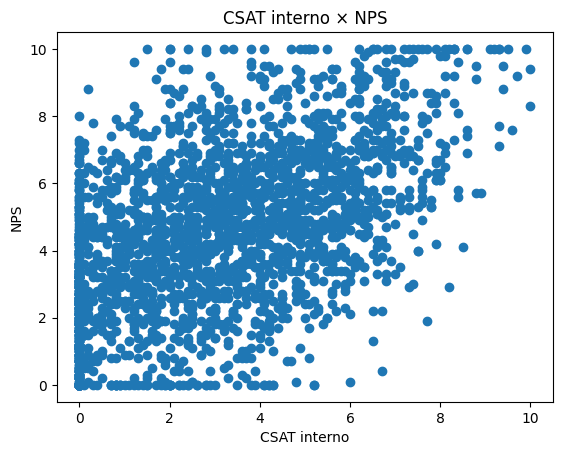

In [ ]:
plt.scatter(dados['csat_internal_score'], dados['nps_score'])
plt.xlabel('CSAT interno')
plt.ylabel('NPS')
plt.title('CSAT interno × NPS')
plt.show()


In [ ]:
dados['csat_internal_score'].corr(dados['nps_score'])

np.float64(0.5630018947390647)

**Resultado:** O CSAT interno apresentou correlação linear positiva de aproximadamente 0,563 com o NPS, indicando uma associação moderada. A hipótese de que valores maiores de CSAT estariam associados a valores maiores de NPS é compatível com o comportamento observado. Contudo, há bastante variabilidade em torno desse padrão. Como a documentação não detalha a composição nem o momento de coleta do CSAT interno, essa associação deve ser interpretada com cautela e o indicador não deve ser tratado automaticamente como antecedente ou fator explicativo do NPS.


# **Resumo**

Na dimensão perfil do cliente, idade e tempo de relacionamento apresentaram associação linear praticamente nula com o NPS, enquanto as distribuições por região foram semelhantes. A recompra em 30 dias apresentou separação perfeita em relação ao ponto de corte de NPS 8, achado que exige investigação antes de qualquer interpretação causal ou uso preditivo.

Na dimensão atendimento, o número de reclamações apresentou a associação linear negativa mais forte com o NPS r ≈ -0,494, seguido pelo número de contatos com o atendimento r ≈ -0,348 e pelo tempo de resolução r ≈ -0,190. O CSAT interno apresentou associação linear positiva moderada r ≈ 0,563, mas sua interpretação é limitada pela ausência de informações sobre sua composição e momento de coleta.

De forma exploratória, os resultados sugerem que reclamações e contatos recorrentes com o atendimento são sinais operacionais relevantes para acompanhar a satisfação do cliente. Esses achados representam associações observadas nesta base e não estabelecem causalidade.
